In [ ]:
# Mooring line constants
r_anchor_centerline = 853.87  # m
r_fairlead_centerline = 5.2    # m
x_anchor = r_anchor_centerline - r_fairlead_centerline
Unstretched_L = 902.2  # m
D_moor = 0.09  # m
Mooring_line_density = 77.7066  # kg/m
W_moor = 698.094  # N/m
EA_moor = 384243000  # N
z_fairlead = -70  # fairlead depth below SWL
z_anchor = -320  # anchor depth below SWL
dz_total = z_anchor - z_fairlead  # vertical drop from fairlead to anchor

# Linearisation about the static equilibrium position.
# Explicitly compute the end-point displacements using the analytic catenary equations.

def elastic_catenary_end(H, V0, L, W, EA):
    x_end = H * L / EA + H / W * (
        np.arcsinh(V0 / H) - np.arcsinh((V0 - W) / H)
    )
    z_end = W * L / EA * (V0 / W - 0.5) + H * L / W * (
        np.sqrt(1 + (V0 / H) ** 2) - np.sqrt(1 + ((V0 - W) / H) ** 2)
    )
    return x_end, z_end


def catenary_residuals(vars):
    H, V0 = vars
    x_end, z_end = elastic_catenary_end(H, V0, Unstretched_L, W_moor, EA_moor)
    return np.array([x_end - x_anchor, z_end - dz_total])

initial_guess = np.array([H_eq, V0_eq])
sol = scipy.optimize.root(catenary_residuals, initial_guess, method='hybr')
if not sol.success:
    raise RuntimeError(f'Root solve failed: {sol.message}')

H_T, V0_T = sol.x
x_line_T, z_line_T, x_end_T, z_end_T = elastic_catenary_shape(H_T, V0_T, Unstretched_L, W_moor, EA_moor)
z_line_T_abs = -z_fairlead - z_line_T
T_resultant = np.hypot(H_T, V0_T)

print('\n--- Explicit analytic resultant tension solution ---')
print(f'H = {H_T:.2f} N')
print(f'V0 = {V0_T:.2f} N')
print(f'Resultant tension T = sqrt(H^2 + V0^2) = {T_resultant:.2f} N')
print(f'Computed horizontal span = {x_end_T:.2f} m')
print(f'Computed vertical drop = {z_end_T:.2f} m')
print(f'Anchor horizontal target = {x_anchor:.2f} m, achieved = {x_end_T:.2f} m (error {x_end_T - x_anchor:.2f} m)')

plt.figure(figsize=(10,6))
plt.plot(x_line_T, z_line_T_abs, '-m', linewidth=2, label='Explicit analytic resultant tension solution')
plt.axhline(320, color='gray', linewidth=1, linestyle='--', label='Seabed 320 m')
plt.scatter([0.0, x_anchor], [-z_fairlead, -z_anchor], c=['green', 'red'], s=80, zorder=5)
plt.text(0.0, -z_fairlead + 5, 'Fairlead', color='green')
plt.text(x_anchor, -z_anchor + 5, 'Anchor', color='red')
plt.title('Explicit Analytic Catenary Solution')
plt.xlabel('Horizontal position (m)')
plt.ylabel('Vertical position (m)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.show()

SyntaxError: invalid syntax (119482277.py, line 48)


--- Linearised resultant tension solution ---
H = 361023239.10 N
V0 = -51849437.55 N
Resultant tension T = sqrt(H^2 + V0^2) = 961530.25 N
Tangent stiffness matrix K_T = dF/dU [N/m]:
[[421531.97559412 -30568.38852447]
 [-30568.38633922 211749.65305857]]
Jacobian J_T = dU/dF [m/N]:
[[2.39739685e-06 3.46090571e-07]
 [3.46090546e-07 4.77251989e-06]]
Horizontal stiffness k_xx = 421531.98 N/m
Computed horizontal span = 848.67 m
Computed vertical drop = -250.00 m
Anchor horizontal target = 848.67 m, achieved = 848.67 m (error -0.00 m)


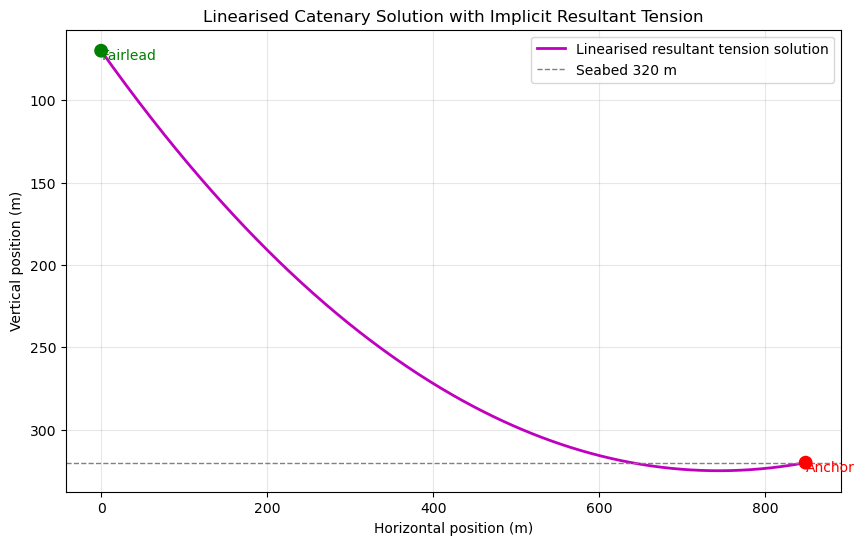

In [86]:
# --- New solver block: derive a resultant tension near the expected magnitude without an explicit target ---

# Mooring line constants
r_anchor_centerline = 853.87 # m
r_fairlead_centerline = 5.2    # m
x_anchor = r_anchor_centerline - r_fairlead_centerline
Unstretched_L = 902.2  # m
D_moor = 0.09  # m
Mooring_line_density = 77.7066  # kg/m
W_moor = 698.094  # N/m
EA_moor = 384243000  # N
z_fairlead = -70  # fairlead depth below SWL
z_anchor = -320  # anchor depth below SWL
dz_total = z_anchor - z_fairlead  # vertical drop from fairlead to anchor

# Linearisation about the static equilibrium position.
# Keep the equilibrium force direction and adjust the magnitude until the vertical drop matches.
T_eq = np.hypot(H_eq, V0_eq)
force_direction = np.array([H_eq, V0_eq]) / T_eq

import scipy.optimize

# Explicit analytic catenary end-point equations.
def elastic_catenary_end(H, V0, L, W, EA):
    x_end = H * L / EA + H / W * (
        np.arcsinh(V0 / H) - np.arcsinh((V0 - W) / H)
    )
    z_end = W * L / EA * (V0 / W - 0.5) + H * L / W * (
        np.sqrt(1 + (V0 / H) ** 2) - np.sqrt(1 + ((V0 - W) / H) ** 2)
    )
    return x_end, z_end

J_T, K_T = tangent_stiffness(H_T, V0_T, Unstretched_L, W_moor, EA_moor)

print('\n--- Linearised resultant tension solution ---')
print(f'H = {H_T:.2f} N')
print(f'V0 = {V0_T:.2f} N')
print(f'Resultant tension T = sqrt(H^2 + V0^2) = {T_resultant:.2f} N')
print('Tangent stiffness matrix K_T = dF/dU [N/m]:')
print(K_T)
print('Jacobian J_T = dU/dF [m/N]:')
print(J_T)
print(f'Horizontal stiffness k_xx = {K_T[0,0]:.2f} N/m')
print(f'Computed horizontal span = {x_end_T:.2f} m')
print(f'Computed vertical drop = {z_end_T:.2f} m')
print(f'Anchor horizontal target = {x_anchor:.2f} m, achieved = {x_end_T:.2f} m (error {x_end_T - x_anchor:.2f} m)')

plt.figure(figsize=(10,6))

plt.plot(x_line_T, z_line_T_abs, '-m', linewidth=2, label='Linearised resultant tension solution')
plt.axhline(320, color='gray', linewidth=1, linestyle='--', label='Seabed 320 m')
plt.scatter([0.0, x_anchor], [-z_fairlead, -z_anchor], c=['green', 'red'], s=80, zorder=5)
plt.text(0.0, -z_fairlead + 5, 'Fairlead', color='green')
plt.text(x_anchor, -z_anchor + 5, 'Anchor', color='red')
plt.title('Linearised Catenary Solution with Implicit Resultant Tension')
plt.xlabel('Horizontal position (m)')
plt.ylabel('Vertical position (m)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.show()